In [59]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('mymoviedb.csv')

Data Cleaning / Quality / Structure / Types

In [60]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,11/24/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,12/22/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [61]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9836 entries, 0 to 9836
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9836 non-null   object 
 1   Title              9827 non-null   object 
 2   Popularity         9826 non-null   float64
 3   Vote_Count         9826 non-null   object 
 4   Vote_Average       9826 non-null   float64
 5   Original_Language  9826 non-null   object 
 6   Genre              0 non-null      object 
 7   Year               9827 non-null   float64
dtypes: float64(3), object(5)
memory usage: 691.6+ KB


In [63]:
df['Year'] = pd.to_datetime(df['Release_Date'], errors='coerce').dt.year

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
 9   Year               9827 non-null   float64
dtypes: float64(2), object(8)
memory usage: 768.6+ KB


In [65]:
df.drop(['Overview','Poster_Url'], axis=1, inplace=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Year
0,12/15/2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",2021.0
1,3/1/2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller",2022.0
2,2/25/2022,No Exit,2618.087,122,6.3,en,Thriller,2022.0
3,11/24/2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",2021.0
4,12/22/2021,The King's Man,1895.511,1793,7,en,"Action, Adventure, Thriller, War",2021.0


In [66]:
df['Original_Language'].unique()

array(['en', 'ja', 'fr', 'hi', 'es', 'ru', 'de', 'th', 'ko', 'tr', 'cn',
       'zh', 'it', 'pt', 'ml', 'pl', 'fi', 'no', 'da', 'id', 'sv', nan,
       'https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg',
       'nl', 'te', 'sr', 'is', 'ro', 'tl', 'fa', 'uk', 'nb', 'eu', 'lv',
       'ar', 'el', 'cs', 'ms', 'bn', 'ca', 'la', 'ta', 'hu', 'he', 'et'],
      dtype=object)

In [67]:
df[df['Original_Language'] == 'https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg']

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Year
1115,- Magic Tricks,61.328,7.1,en,Animation,https://image.tmdb.org/t/p/original/6iXYe7AkQ1...,NaN,NaN


In [68]:
df.drop(index=1115, inplace=True)

In [69]:
df['Original_Language'].unique()

array(['en', 'ja', 'fr', 'hi', 'es', 'ru', 'de', 'th', 'ko', 'tr', 'cn',
       'zh', 'it', 'pt', 'ml', 'pl', 'fi', 'no', 'da', 'id', 'sv', nan,
       'nl', 'te', 'sr', 'is', 'ro', 'tl', 'fa', 'uk', 'nb', 'eu', 'lv',
       'ar', 'el', 'cs', 'ms', 'bn', 'ca', 'la', 'ta', 'hu', 'he', 'et'],
      dtype=object)

In [70]:
df['Genre'].unique()

array(['Action, Adventure, Science Fiction', 'Crime, Mystery, Thriller',
       'Thriller', ..., 'Comedy, TV Movie, Romance',
       'Science Fiction, Fantasy, Family, Music',
       'War, Drama, Science Fiction'], shape=(2338,), dtype=object)

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.drop_duplicates(inplace=True)

In [73]:
df.duplicated().sum()

np.int64(0)

Q.What are the most popular movie genre?

C:\Users\Basel\AppData\Local\Temp\ipykernel_14588\4166598233.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_popularity, x='Popularity', y='Genre', palette='viridis', legend=False)


Text(0.5, 1.0, 'Genre Popularity')

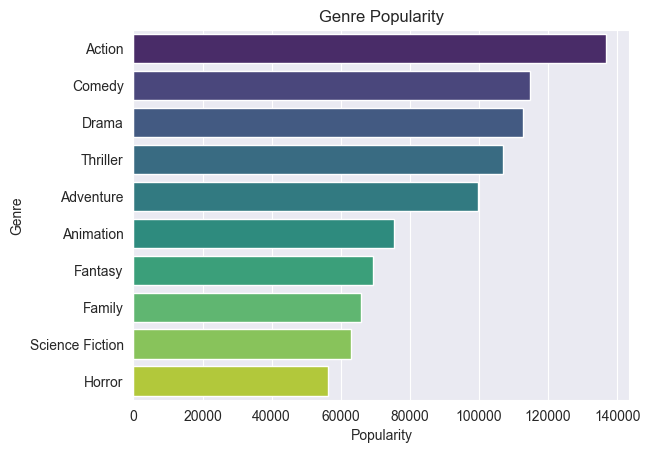

In [74]:
df['Genre'] = df['Genre'].str.split(', ')
df_exploded = df.explode('Genre')

genre_popularity = df_exploded.groupby('Genre')['Popularity'].sum().reset_index()
genre_popularity = genre_popularity.sort_values('Popularity', ascending=False).head(10)

sns.barplot(data=genre_popularity, x='Popularity', y='Genre', palette='viridis', legend=False)
plt.title('Genre Popularity')


No single genre dominates entirely the top genre Action only accounts for nearly 12% of total popularity meaning audience interest is spread fairly evenly across genres.

Q.What are the most popular movies?

C:\Users\Basel\AppData\Local\Temp\ipykernel_14588\2176775226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, x='Popularity', y='Title', palette='magma')


Text(0.5, 1.0, 'Top 10 Movies')

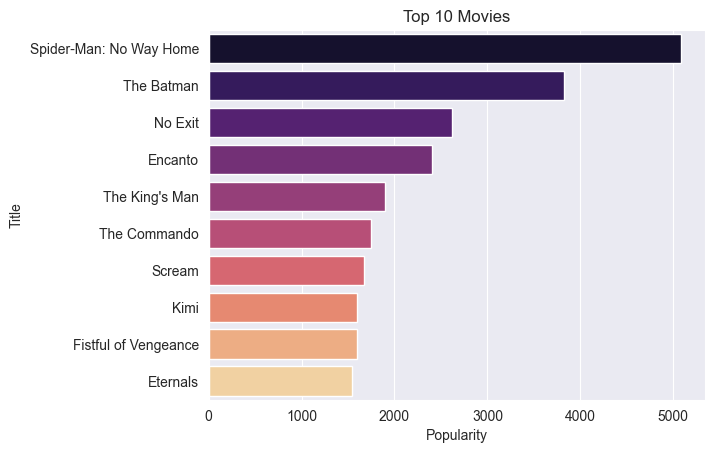

In [75]:
top_movies = df[['Title', 'Popularity', 'Genre', 'Vote_Average']] .sort_values('Popularity', ascending=False).head(10)

sns.barplot(data=top_movies, x='Popularity', y='Title', palette='magma')
plt.title('Top 10 Movies')

Spider-Man: No Way Home is by far the most popular at with more than 5000

The Batman comes 2nd with slightly less than 4000

Q. What is the genre of the highest rated movie?

In [76]:
df[df['Title'] == 'Spider-Man: No Way Home'][['Title', 'Genre', 'Popularity']]

,Title,Genre,Popularity
0,Spider-Man: No Way Home,"[Action, Adventure, Science Fiction]",5083.954


Q.Does the original language affect the movie popularity?

C:\Users\Basel\AppData\Local\Temp\ipykernel_14588\1942627175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_pop, x='Popularity', y='Original_Language',palette='coolwarm')


Text(0.5, 1.0, 'Top 10 Languages')

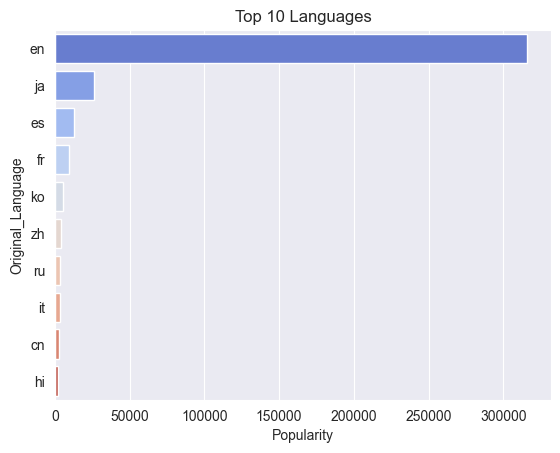

In [77]:
lang_pop = df.groupby('Original_Language')['Popularity'].sum().reset_index()
lang_pop = lang_pop.sort_values('Popularity', ascending=False).head(10)

sns.barplot(data=lang_pop, x='Popularity', y='Original_Language',palette='coolwarm')
plt.title('Top 10 Languages')


English dominates the language popularity, since both Spider-Man and Batman are English (en) they benefit from the most popular language.

What year was the largest number of films produced?

Text(0.5, 1.0, 'Number of Films by Year')

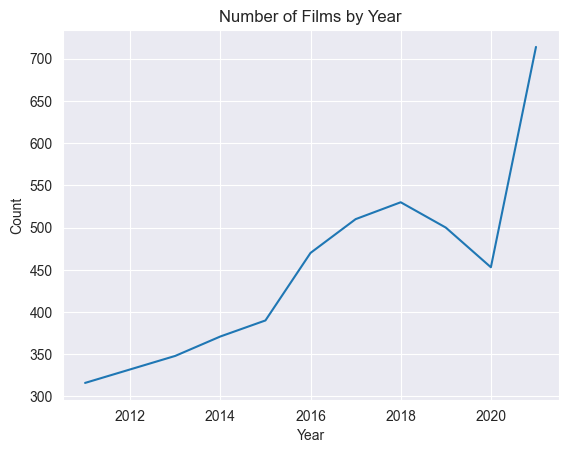

In [78]:
year_counts = df.groupby('Year')['Title'].count().reset_index()
year_counts.columns = ['Year', 'Count']
year_counts = year_counts.sort_values('Count', ascending=False).head(10)

sns.lineplot(x='Year', y='Count', data=year_counts)
plt.title('Number of Films by Year')

Q. What are the highest rated genres?


C:\Users\Basel\AppData\Local\Temp\ipykernel_14588\3657819262.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_rating, x='Vote_Average', y='Genre', palette='RdYlGn')


Text(0.5, 1.0, 'Average Movie Rating by Genre')

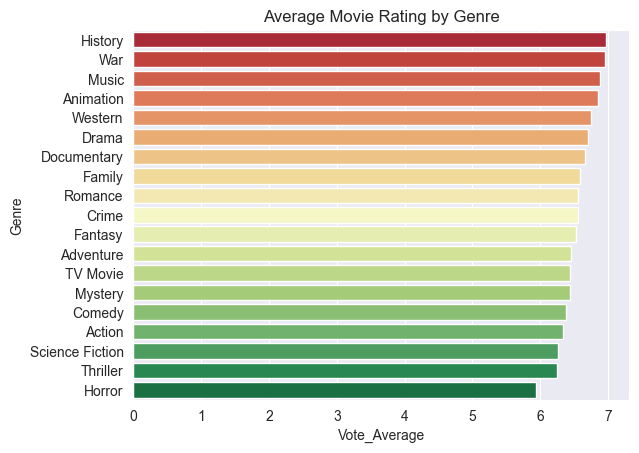

In [83]:
df = pd.read_csv('mymoviedb.csv')

df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')

genre_rating = df.groupby('Genre')['Vote_Average'].mean().reset_index()
genre_rating = genre_rating.sort_values('Vote_Average', ascending=False)

sns.barplot(data=genre_rating, x='Vote_Average', y='Genre', palette='RdYlGn')
plt.title('Average Movie Rating by Genre')

The highest rated genres are not the most popular ones

Q. Is there any relation between vote count and vote average?

Text(0.5, 1.0, 'Vote Count vs Vote Average')

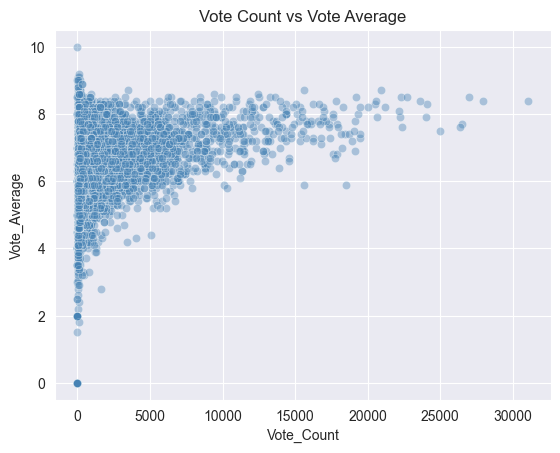

In [85]:
df = pd.read_csv('mymoviedb.csv', encoding='utf-8-sig')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

sns.scatterplot(data=df, x='Vote_Count', y='Vote_Average', alpha=0.4, color='steelblue')

plt.title('Vote Count vs Vote Average')

Movies with few votes have unpredictable ratings (ranging from 0 to 10), while movies with more votes stabilize between 7–9, proving that vote count is a reliable indicator of rating trustworthiness.

Movie Genre Trends Overtime

Text(0, 0.5, 'Number of Movies')

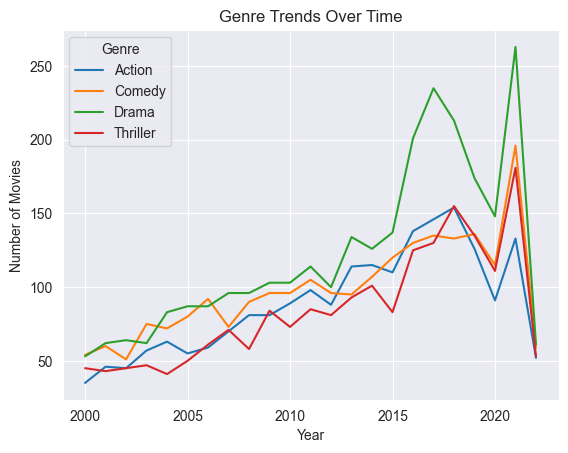

In [91]:
df = pd.read_csv('mymoviedb.csv')
df['Year'] = pd.to_datetime(df['Release_Date'], errors='coerce').dt.year
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')

top_genres = df['Genre'].value_counts().head(4).index
df = df[df['Genre'].isin(top_genres)]

genre_trend = df.groupby(['Year', 'Genre'])['Title'].count().reset_index()
genre_trend.columns = ['Year', 'Genre', 'Count']

genre_trend = genre_trend[genre_trend['Year'].between(2000, 2022)]

sns.lineplot(data=genre_trend, x='Year', y='Count', hue='Genre')
plt.title('Genre Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

Drama has dominated and grown the fastest since 2000, peaking at 265 movies in 2021, while Action, Comedy, and Thriller grew steadily but closely together throughout the years.
The COVID dip in 2020 hit all genres equally